# Predicting Type 2 Diabetes Risk Using BRFSS 2023

This project develops an interpretable machine-learning workflow for estimating Type 2 diabetes risk using selected Behavioral Risk Factor Surveillance System (BRFSS) 2023 variables. The workflow covers data cleaning, exploratory data analysis, baseline and tree-based models, model comparison, feature interpretation, and public-health recommendations.


## Apex Project Team

| Name | GitHub | Role |
|------|--------|------|
| Stephen Mwaura | **@S-Mwaura** | Project Lead · Modeling |
| Angela Masaki | **@MoonwaMasaki** | Data Engineering · Exploratory Data Analysis (EDA) |
| Diana Byegon | **@byegond-beep** | Feature Engineering · Model Evaluation |
| Kevin Kisengu | **@K-OK27** | Model Explainability (SHAP & LIME) |
| Orandi Felix | **@Orandifelix** | Documentation · Modeling |

## 1. Business Understanding

Type 2 Diabetes Mellitus (T2DM) is a major public health challenge affecting over 500 million people worldwide and is one of the fastest-growing chronic diseases globally (International Diabetes Federation, 2021) which contributes to increased healthcare costs, reduced quality of life, and a higher risk of complications such as cardiovascular disease, kidney disease, and stroke. Early identification of individuals at high risk enables healthcare providers to implement preventive interventions, promote healthy lifestyle changes, and improve disease management. This project develops a machine learning model to predict the likelihood of Type 2 Diabetes using demographic, behavioral, and clinical risk factors collected through the Behavioral Risk Factor Surveillance System (BRFSS) 2023 survey

### Problem Statement

Early detection of Type 2 Diabetes remains a challenge because many individuals are undiagnosed until complications develop. Traditional screening methods may not efficiently identify high-risk individuals across large populations. Therefore, there is a need for a predictive model that can accurately classify individuals as having diabetes or not using readily available health survey data. Such a model can support healthcare professionals in prioritizing screening efforts and designing targeted prevention programs.

### Objectives

- Clean and prepare BRFSS survey variables for machine learning.
- Explore demographic, behavioral, and clinical factors associated with diabetes.
- Train and compare Logistic Regression, Decision Tree, Random Forest, and XGBoost classifiers.
- Identify the most influential predictors and translate them into actionable recommendations.
- To implement SHAP and LIME for model explainability
- To develop an interactive dashboard for disease risk prediction and visualization

### Stakeholders
#### Primary Stakeholders
- Clinicians and other healthcare providers
- Patients and individuals at risk of T2DM
- Public health agencies and health promotion programs

#### Secondary Stakeholders
- Researchers and academic institutions
- Health insurance organizations
- Policy makers focused on reducing diabetes prevalence
- NGOs and community health organizations

### Success Metrics

Because diabetes screening is a risk-identification problem, the priority is not only overall accuracy. The key metrics are:

- At least one machine learning model achieves an **ROC-AUC** of ≥80% on the test set.
- **ROC-AUC:** overall discrimination between diabetic and non-diabetic respondents.
- **Recall for diabetes:** ability to identify respondents with diabetes.
- **Precision for diabetes:** share of predicted diabetes cases that are truly diabetes cases.
- **F1-score:** balance between precision and recall.
- **SHAP and LIME** explanations are successfully generated and visualized
- The **Streamlit** dashboard runs without errors and displays all required outputs


## 2. Dataset

### Dataset Overview

The project uses the Behavioral Risk Factor Surveillance System (BRFSS) 2023 dataset, a nationally representative health survey conducted annually by the Centers for Disease Control and Prevention (CDC). The dataset contains self-reported information on demographics, health conditions, lifestyle behaviors, and access to healthcare collected from U.S. adults through telephone interviews.

**Dataset Details:**
- Dataset: [BRFSS 2023](https://www.cdc.gov/brfss/annual_data/annual_2023.html)
- Observations: 433,323 respondents
- Features: 350 variables
- Survey Type: Cross-sectional telephone survey

The target is `DIABETE4`, recoded as:

- `1`: respondent has diabetes.
- `0`: respondent does not have diabetes.

Respondents reporting prediabetes, gestational diabetes only, don't know/not sure, refused, or missing diabetes status are excluded from the supervised modeling target to keep the classification task focused on diagnosed diabetes versus no diabetes.

### Features Selected

The model uses 14 predictor variables selected because they are established risk factors for diabetes. They represent demographic, lifestyle, socioeconomic, health status, and clinical characteristics while avoiding variables that directly indicate diabetes diagnosis.

| Feature | Description | Reason for Inclusion |
|---------|-------------|---------------------|
| **`_BMI5`** | Body Mass Index | Higher BMI increases diabetes risk |
| **`_AGE80`** | Age | Diabetes risk increases with age |
| **`SEXVAR`** | Sex | Diabetes risk differs between males and females |
| **`_IMPRACE`** | Race/Ethnicity | Diabetes prevalence varies across population groups |
| **`GENHLTH`** | General Health | Poor health is associated with chronic disease |
| **`PHYSHLTH`** | Physical Health | Frequent poor health may indicate underlying illness |
| **`SMOKE100`** | Ever Smoked | Smoking increases diabetes risk |
| **`_TOTINDA`** | Physical Activity | Regular activity lowers diabetes risk |
| **`EDUCA`** | Education | Education influences health awareness and behaviors |
| **`INCOME3`** | Income | Income affects access to healthcare and healthy living |
| **`_RFHYPE6`** | Hypertension | High blood pressure commonly coexists with diabetes |
| **`_RFCHOL3`** | High Cholesterol | Linked to metabolic disorders and diabetes |
| **`CHCKDNY2`** | Kidney Disease | Strongly associated with diabetes |
| **`_MICHD`** | Heart Disease | Shares major risk factors with diabetes |



## 3. Import Required Libraries


In [1]:
# Data manipulation

import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Modeling and preprocessing
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    RocCurveDisplay,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
# Model persistence
import joblib
# Explainability
import shap
from lime.lime_tabular import LimeTabularExplainer
# Set global settings
sns.set_theme(style="whitegrid", palette="Set2")
pd.set_option("display.max_columns", 100)
RANDOM_STATE = 42
# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

c:\Users\Stephen\anaconda3\envs\learn-env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 4. Load Data


In [ ]:

# Load the dataset 
DATA_PATH = "../datasets/raw/CDC_LLCP2023.XPT"

df = pd.read_sas(DATA_PATH, format="xport")

# Display the first few rows of the dataset
df.head()


,_STATE,FMONTH,IDATE,IMONTH,IDAY,IYEAR,DISPCODE,SEQNO,_PSU,CTELENM1,PVTRESD1,COLGHOUS,STATERE1,CELPHON1,LADULT1,NUMADULT,RESPSLC1,LANDSEX2,LNDSXBRT,SAFETIME,CTELNUM1,CELLFON5,CADULT1,CELLSEX2,CELSXBRT,PVTRESD3,CCLGHOUS,CSTATE1,LANDLINE,HHADULT,SEXVAR,GENHLTH,PHYSHLTH,MENTHLTH,POORHLTH,PRIMINS1,PERSDOC3,MEDCOST1,CHECKUP1,EXERANY2,EXRACT12,EXEROFT1,EXERHMM1,EXRACT22,EXEROFT2,EXERHMM2,STRENGTH,BPHIGH6,BPMEDS1,CHOLCHK3,...,_PACAT3,_PAINDX3,_PA150R4,_PA300R4,_PA30023,_PASTRNG,_PAREC3,_PASTAE3,_RFHYPE6,_CHOLCH3,_RFCHOL3,_MICHD,_LTASTH1,_CASTHM1,_ASTHMS1,_DRDXAR2,_MRACE1,_HISPANC,_RACE,_RACEG21,_RACEGR3,_RACEPRV,_SEX,_AGEG5YR,_AGE65YR,_AGE80,_AGE_G,HTIN4,HTM4,WTKG3,_BMI5,_BMI5CAT,_RFBMI5,_CHLDCNT,_EDUCAG,_INCOMG1,_SMOKER3,_RFSMOK3,_CURECI2,DRNKANY6,DROCDY4_,_RFBING6,_DRNKWK2,_RFDRHV8,_FLSHOT7,_PNEUMO3,_AIDTST4,_RFSEAT2,_RFSEAT3,_DRNKDRV
0,1.0,1.0,b'03012023',b'03',b'01',b'2023',1100.0,b'2023000001',2.023000e+09,1.0,1.0,NaN,1.0,2.0,1.0,2.0,1.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,2.0,88.0,88.0,NaN,3.0,1.0,2.0,2.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,888.0,1.0,1.0,3.0,...,4.0,2.0,3.0,3.0,2.0,2.0,4.0,2.0,2.0,1.0,1.0,2.0,1.0,1.0,3.0,2.0,1.0,2.0,1.0,1.0,1.0,1.0,2.0,13.0,2.0,80.0,6.0,63.0,160.0,7802.0,3047.0,4.0,2.0,1.0,3.0,9.0,4.0,1.0,1.0,2.0,5.397605e-79,1.0,5.397605e-79,1.0,2.0,2.0,2.0,1.0,1.0,9.0
1,1.0,1.0,b'01062023',b'01',b'06',b'2023',1100.0,b'2023000002',2.023000e+09,1.0,1.0,NaN,1.0,2.0,1.0,1.0,NaN,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,2.0,88.0,88.0,NaN,3.0,1.0,2.0,2.0,1.0,1.0,106.0,30.0,88.0,NaN,NaN,888.0,1.0,2.0,2.0,...,1.0,1.0,1.0,1.0,1.0,2.0,2.0,2.0,2.0,1.0,2.0,2.0,1.0,1.0,3.0,1.0,1.0,2.0,1.0,1.0,1.0,1.0,2.0,13.0,2.0,80.0,6.0,57.0,145.0,5987.0,2856.0,3.0,2.0,1.0,3.0,9.0,4.0,1.0,1.0,2.0,5.397605e-79,1.0,5.397605e-79,1.0,1.0,1.0,2.0,1.0,1.0,9.0
2,1.0,1.0,b'03082023',b'03',b'08',b'2023',1100.0,b'2023000003',2.023000e+09,1.0,1.0,NaN,1.0,2.0,1.0,1.0,NaN,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,4.0,6.0,2.0,1.0,3.0,1.0,1.0,1.0,1.0,1.0,205.0,15.0,88.0,NaN,NaN,205.0,1.0,1.0,2.0,...,9.0,9.0,9.0,9.0,9.0,2.0,9.0,9.0,2.0,1.0,2.0,2.0,2.0,2.0,1.0,1.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,13.0,2.0,80.0,6.0,64.0,163.0,5897.0,2231.0,2.0,1.0,1.0,2.0,1.0,3.0,1.0,1.0,2.0,5.397605e-79,1.0,5.397605e-79,1.0,1.0,1.0,2.0,1.0,1.0,9.0
3,1.0,1.0,b'03062023',b'03',b'06',b'2023',1100.0,b'2023000004',2.023000e+09,1.0,1.0,NaN,1.0,2.0,1.0,2.0,1.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,2.0,2.0,88.0,88.0,3.0,1.0,2.0,3.0,1.0,1.0,103.0,30.0,88.0,NaN,NaN,888.0,3.0,NaN,3.0,...,9.0,1.0,1.0,9.0,9.0,2.0,2.0,2.0,1.0,1.0,1.0,2.0,1.0,1.0,3.0,1.0,1.0,2.0,1.0,1.0,1.0,1.0,2.0,12.0,2.0,78.0,6.0,66.0,168.0,7711.0,2744.0,3.0,2.0,1.0,3.0,9.0,4.0,1.0,1.0,2.0,5.397605e-79,1.0,5.397605e-79,1.0,1.0,1.0,1.0,1.0,1.0,9.0
4,1.0,1.0,b'01062023',b'01',b'06',b'2023',1100.0,b'2023000005',2.023000e+09,1.0,1.0,NaN,1.0,2.0,1.0,1.0,NaN,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,4.0,88.0,88.0,NaN,3.0,1.0,2.0,1.0,1.0,1.0,102.0,45.0,8.0,107.0,100.0,888.0,1.0,1.0,2.0,...,1.0,1.0,1.0,1.0,1.0,2.0,2.0,2.0,2.0,1.0,1.0,2.0,1.0,1.0,3.0,1.0,1.0,2.0,1.0,1.0,1.0,1.0,2.0,12.0,2.0,76.0,6.0,68.0,173.0,7711.0,2585.0,3.0,2.0,1.0,3.0,5.0,4.0,1.0,1.0,1.0,7.000000e+00,1.0,4.700000e+01,1.0,2.0,1.0,2.0,1.0,1.0,2.0


In [3]:
# Display basic information about the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 433323 entries, 0 to 433322
Columns: 350 entries, _STATE to _DRNKDRV
dtypes: float64(345), object(5)
memory usage: 1.1+ GB


## 5. Target and Feature Selection


In [4]:
# Define the target variable and features
target = "DIABETE4"

# Define the features to be used in the model
features = [
    "_BMI5",       # Body mass index, stored as BMI * 100
    "_AGE80",      # Imputed age, top-coded at 80
    "SEXVAR",      # Sex
    "_IMPRACE",    # Imputed race/ethnicity
    "GENHLTH",     # General health
    "PHYSHLTH",    # Days physical health was not good in past 30 days
    "SMOKE100",    # Smoked at least 100 cigarettes in lifetime
    "_TOTINDA",    # Physical activity indicator
    "EDUCA",       # Education
    "INCOME3",     # Income
    "_RFHYPE6",    # Hypertension risk factor recode
    "_RFCHOL3",    # High cholesterol risk factor recode
    "CHCKDNY2",    # Kidney disease
    "_MICHD",      # Coronary heart disease / myocardial infarction
]

In [5]:
# Rename selected columns for readability
df = df.rename(columns={
    "DIABETE4": "Diabetes_Status",
    "_BMI5": "BMI",
    "_AGE80": "Age",
    "SEXVAR": "Sex",
    "_IMPRACE": "Race_Ethnicity",
    "GENHLTH": "General_Health",
    "PHYSHLTH": "Physical_Health",
    "SMOKE100": "Ever_Smoked",
    "_TOTINDA": "Physical_Activity",
    "EDUCA": "Education_Level",
    "INCOME3": "Income_Level",
    "_RFHYPE6": "Hypertension",
    "_RFCHOL3": "High_Cholesterol",
    "CHCKDNY2": "Kidney_Disease",
    "_MICHD": "Heart_Disease"
})

In [6]:
# Define the target variable
target = "Diabetes_Status"

# Define the feature variables
features = [
    "BMI",
    "Age",
    "Sex",
    "Race_Ethnicity",
    "General_Health",
    "Physical_Health",
    "Ever_Smoked",
    "Physical_Activity",
    "Education_Level",
    "Income_Level",
    "Hypertension",
    "High_Cholesterol",
    "Kidney_Disease",
    "Heart_Disease",
]

## 6. Initial Data Audit


In [7]:
# Check for missing values and duplicates of the dataset
audit_cols = features + [target]
# Summarize missing values and unique values for the selected columns
missing_summary = (
    pd.DataFrame({
        "missing_count": df[audit_cols].isna().sum(),
        "missing_percent": (df[audit_cols].isna().mean() * 100).round(2),
        "unique_values": df[audit_cols].nunique(dropna=True),
    })
    .sort_values("missing_percent", ascending=False)
)
# Display the summary of missing values and unique values
duplicate_count = df.duplicated().sum()
print(f"Duplicate rows in full dataset: {duplicate_count:,}")
missing_summary


Duplicate rows in full dataset: 0


,missing_count,missing_percent,unique_values
High_Cholesterol,51811,11.96,3
BMI,40535,9.35,4099
Ever_Smoked,19674,4.54,4
Income_Level,8075,1.86,13
Heart_Disease,4585,1.06,2
Sex,0,0.00,2
Age,0,0.00,63
Physical_Health,3,0.00,33
General_Health,4,0.00,7
Race_Ethnicity,0,0.00,6


#### Missing Values Analysis:

- High_Cholesterol has 11.96% missing (51,811 observations)

- BMI has 9.35% missing (40,535 observations)

- Ever_Smoked has 4.54% missing (19,674 observations)

- Income_level has 1.86% missing (8,075 observations)

- Heart_Disease has 1.06% missing (4,585 observations)

- Other features have minimal missing values (< 0.01%)
#### Duplicate analysis
- There are no duplicate records in the dataset

In [8]:
# Inspect response-code distributions for variables with special survey codes.
special_codes = {
    "General_Health": [7, 9],          # Don't know / refused
    "Physical_Health": [77, 88, 99],   # Don't know / none / refused
    "Ever_Smoked": [7, 9],         # Don't know / refused
    "Physical_Activity": [9],            # Don't know / refused / missing
    "Education_Level": [9],               # Refused
    "Income_Level": [77, 99],        # Don't know / refused
    "Hypertension": [9],            # Don't know / refused / missing
    "High_Cholesterol": [9],            # Don't know / refused / missing
    "Kidney_Disease": [7, 9],         # Don't know / refused
    "Heart_Disease": [7, 9],           # Don't know / refused, if present
    "Diabetes_Status": [2, 4, 7, 9],   # Pregnancy-only, prediabetes, don't know, refused
}

special_code_rows = []

for col, codes in special_codes.items():
    counts = df[col].value_counts(dropna=False)

    for code in codes:
        count = counts.get(code, 0)

        special_code_rows.append({
            "feature": col,
            "special_code": code,
            "count": count,
            "percent": round(count / len(df) * 100, 2)
        })

special_code_summary = pd.DataFrame(special_code_rows)

special_code_summary.sort_values(
    ["feature", "special_code"]
)

,feature,special_code,count,percent
17,Diabetes_Status,2,3253,0.75
18,Diabetes_Status,4,10594,2.44
19,Diabetes_Status,7,683,0.16
20,Diabetes_Status,9,296,0.07
8,Education_Level,9,2316,0.53
5,Ever_Smoked,7,2251,0.52
6,Ever_Smoked,9,643,0.15
0,General_Health,7,897,0.21
1,General_Health,9,361,0.08
15,Heart_Disease,7,0,0.00


## 7. Data Cleaning

The CDC survey uses numeric response codes. Several values represent non-analytic responses such as "don't know", "refused", or missing. The cleaning strategy below:

- Excludes target responses that do not represent diagnosed diabetes versus no diabetes.
- Converts BMI from `_BMI5` scale units to standard BMI.
- Recodes binary health indicators so `1` consistently means the risk factor or condition is present and `0` means absent.
- Converts non-informative survey codes to missing values before imputation.
- Keeps imputation inside the modeling pipeline to avoid data leakage.


In [9]:
# Clean special BRFSS response codes

# Physical_Health:
# 88 = None / zero days, so recode to 0
# 77 = Don't know, 99 = Refused, so set to NaN
df["Physical_Health"] = df["Physical_Health"].replace({
    88: 0,
    77: np.nan,
    99: np.nan
})

# Standard don't know / refused codes
df["General_Health"] = df["General_Health"].replace([7, 9], np.nan)
df["Ever_Smoked"] = df["Ever_Smoked"].replace([7, 9], np.nan)
df["Physical_Activity"] = df["Physical_Activity"].replace(9, np.nan)
df["Education_Level"] = df["Education_Level"].replace(9, np.nan)
df["Kidney_Disease"] = df["Kidney_Disease"].replace([7, 9], np.nan)

# Income special codes
df["Income_Level"] = df["Income_Level"].replace([77, 99], np.nan)

# Risk-factor recodes
df["Hypertension"] = df["Hypertension"].replace(9, np.nan)
df["High_Cholesterol"] = df["High_Cholesterol"].replace(9, np.nan)


Most special response codes represent non-analytic answers such as "don't know" or "refused" and were converted to missing values. The exception is `PHYSHLTH = 88`, which means the respondent had zero poor physical-health days in the past month, so it was recoded to `0` rather than removed or imputed. 

In [10]:
# Target cleaning
# Keep only diagnosed diabetes and no diabetes
df = df[df["Diabetes_Status"].isin([1, 3])].copy()
# Map target variable to binary values
df["Diabetes_Status"] = df["Diabetes_Status"].map({
    1: 1,  # Diabetes
    3: 0   # No diabetes
})

For the target variable, only `DIABETE4 = 1` diagnosed diabetes and `DIABETE4 = 3` no diabetes were retained. Prediabetes, pregnancy-only diabetes, don't know, and refused responses were excluded from the binary classification target.

In [11]:
# Create a new DataFrame for modeling with selected features and target
ml_df = df[features + [target]].copy()

In [12]:
# Scale BMI to standard units (kg/m^2) by dividing by 100
ml_df["BMI"] = ml_df["BMI"] / 100

In [13]:
# Summary of data cleaning
cleaning_summary = pd.DataFrame({
    "missing_count": ml_df[features + [target]].isna().sum(),
    "missing_percent": (ml_df[features + [target]].isna().mean() * 100).round(2),
    "unique_values": ml_df[features + [target]].nunique(dropna=True),
})

cleaning_summary.sort_values("missing_percent", ascending=False)


,missing_count,missing_percent,unique_values
Income_Level,83361,19.92,11
High_Cholesterol,53416,12.76,2
BMI,38910,9.30,4033
Ever_Smoked,21776,5.20,2
Physical_Health,10152,2.43,31
Heart_Disease,4077,0.97,2
Education_Level,2146,0.51,6
Hypertension,1646,0.39,2
Kidney_Disease,1522,0.36,2
Physical_Activity,1159,0.28,2


After cleaning special BRFSS response codes, the highest missingness appears in `INCOME3` (19.92%), `_RFCHOL3` (12.76%), `_BMI5` (9.30%), and `SMOKE100` (5.20%). These variables will not be dropped because removing all rows with missing predictor values would discard a large amount of useful survey data. Instead, missing predictor values will be handled with imputation after the train-test split to avoid data leakage.

In [14]:
# Map categorical variables to binary values for modeling
ml_df["Hypertension"] = ml_df["Hypertension"].map({
    1: 0,  # No hypertension
    2: 1   # Hypertension
})

ml_df["High_Cholesterol"] = ml_df["High_Cholesterol"].map({
    1: 0,  # No high cholesterol
    2: 1   # High cholesterol
})

ml_df["Kidney_Disease"] = ml_df["Kidney_Disease"].map({
    1: 1,  # Kidney disease
    2: 0   # No kidney disease
})

ml_df["Heart_Disease"] = ml_df["Heart_Disease"].map({
    1: 1,  # Heart disease
    2: 0   # No heart disease
})

ml_df["Ever_Smoked"] = ml_df["Ever_Smoked"].map({
    1: 1,  # Smoked 100 cigarettes
    2: 0   # Did not smoke 100 cigarettes
})

ml_df["Physical_Activity"] = ml_df["Physical_Activity"].map({
    1: 1,  # Physically active
    2: 0   # Not physically active
})

### Cleaning Notes

Missing values remain in predictor columns by design. They are handled inside the preprocessing pipeline after the train/test split, which prevents information from the test set from influencing imputation values learned from training data.

## 8. Exploratory Data Analysis
### 8.1. Univariate analysis
### 8.1.1 Target Distribution


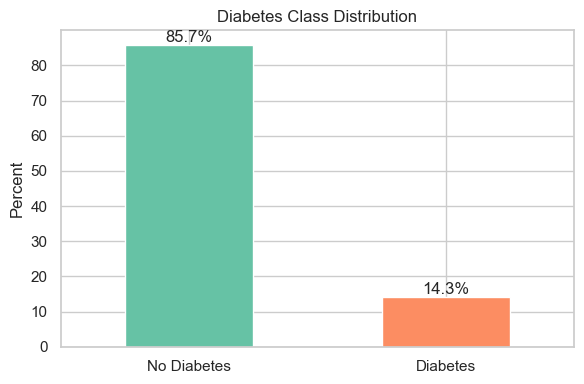

In [15]:
# Visualize the distribution of the target variable
# Create a bar plot to show the distribution of diabetes and no diabetes in the dataset
target_dist = ml_df[target].value_counts(normalize=True).sort_index() * 100

ax = target_dist.plot(kind="bar", figsize=(6, 4), color=["#66c2a5", "#fc8d62"])
ax.set_xticklabels(["No Diabetes", "Diabetes"], rotation=0)
ax.set_ylabel("Percent")
ax.set_xlabel("")
ax.set_title("Diabetes Class Distribution")

for p in ax.patches:
    ax.annotate(f"{p.get_height():.1f}%", (p.get_x() + p.get_width() / 2, p.get_height()),
                ha="center", va="bottom")

plt.tight_layout()
plt.show()


### 8.2. Multivariate analysis
### 8.2.1 Correlation heatmap of the target variable and the features

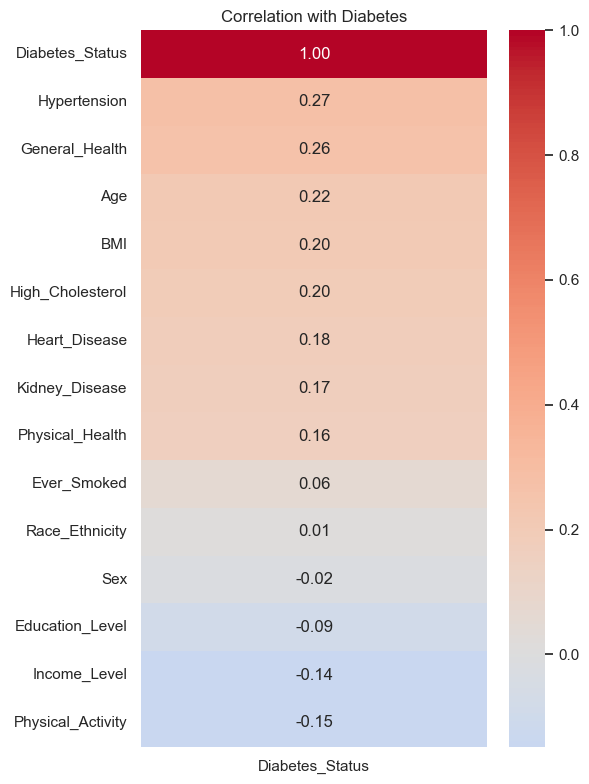

In [16]:
# Visualize correlations of features with diabetes
numeric_for_corr = ml_df.copy()
corr_target = (
    numeric_for_corr[features + [target]]
    .corr(numeric_only=True)[[target]]
    .sort_values(target, ascending=False)
)

plt.figure(figsize=(6, 8))
sns.heatmap(corr_target, annot=True, cmap="coolwarm", center=0, fmt=".2f")
plt.title("Correlation with Diabetes")
plt.tight_layout()
plt.show()


Hypertension shows the strongest positive correlation with diabetes (r = 0.27), followed by poor general health (r = 0.26), age (r = 0.22), BMI (r = 0.20) and high cholesterol (r = 0.20), and . Heart and kidney disease also show modest positive associations. Physical activity has a weak positive correlation (r = 0.16), likely reflecting behavioral changes after diagnosis rather than a causal effect. Race shows nearly no linear relationship, while income and education are negatively correlated with diabetes. Smoking, sex, and physical health days show very weak associations.

### 8.3. Bivariate analysis
#### 8.3.1 Diabetes rate by Hypertension

In [17]:
# Diabetes rate by hypertension
# Calculate diabetes rate by hypertension status
hypertension_rate = (
    ml_df.groupby("Hypertension")["Diabetes_Status"]
    .mean()
    .mul(100)
    .reset_index()
)

hypertension_rate["Hypertension"] = hypertension_rate["Hypertension"].map({
    0: "No Hypertension",
    1: "Hypertension"
})

hypertension_rate

,Hypertension,Diabetes_Status
0,No Hypertension,6.351184
1,Hypertension,25.933252


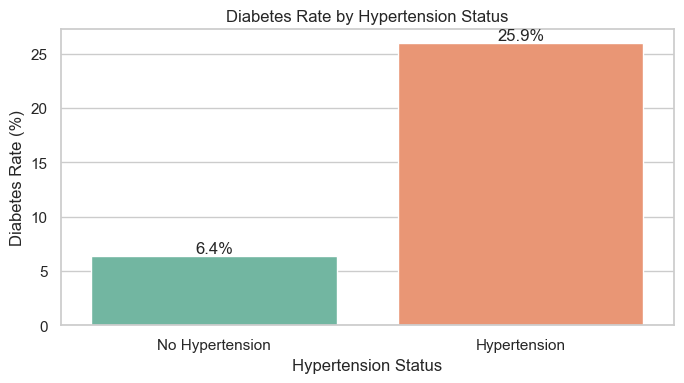

In [18]:
# Visualize diabetes rate by hypertension status
plt.figure(figsize=(7, 4))

ax = sns.barplot(
    data=hypertension_rate,
    x="Hypertension",
    y="Diabetes_Status",
    palette=["#66c2a5", "#fc8d62"]
)

plt.xlabel("Hypertension Status")
plt.ylabel("Diabetes Rate (%)")
plt.title("Diabetes Rate by Hypertension Status")

for p in ax.patches:
    ax.annotate(
        f"{p.get_height():.1f}%",
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

The chart shows a strong relationship between hypertension and diabetes. Among respondents without hypertension, the diabetes rate is only 6.4%, while among respondents with hypertension, it rises to 25.9%.
This means people with hypertension have about 4 times higher diabetes prevalence than those without hypertension.

### 8.3.2 Diabetes rate by cholesterol levels

In [19]:
# Diabetes rate by cholesterol
# Calculate diabetes rate by cholesterol status
cholesterol_rate = (
    ml_df.groupby("High_Cholesterol")["Diabetes_Status"]
    .mean()
    .mul(100)
    .reset_index()
)

cholesterol_rate["High_Cholesterol"] = cholesterol_rate["High_Cholesterol"].map({
    0: "No High Cholesterol",
    1: "High Cholesterol"
})

cholesterol_rate

,High_Cholesterol,Diabetes_Status
0,No High Cholesterol,9.468580
1,High Cholesterol,23.961015


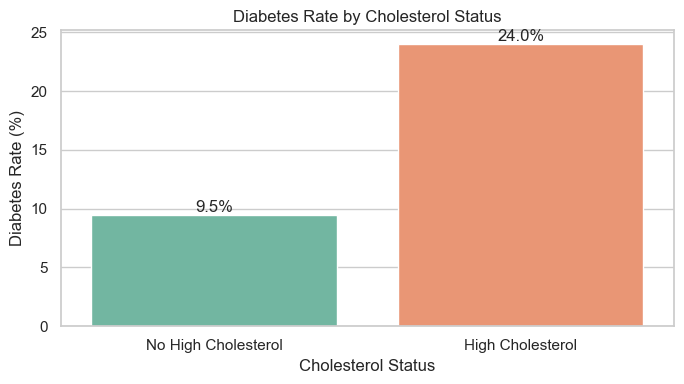

In [20]:
# Visualize diabetes rate by cholesterol status
plt.figure(figsize=(7, 4))

ax = sns.barplot(
    data=cholesterol_rate,
    x="High_Cholesterol",
    y="Diabetes_Status",
    palette=["#66c2a5", "#fc8d62"]
)

plt.xlabel("Cholesterol Status")
plt.ylabel("Diabetes Rate (%)")
plt.title("Diabetes Rate by Cholesterol Status")

for p in ax.patches:
    ax.annotate(
        f"{p.get_height():.1f}%",
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

The chart shows that diabetes is much more common among respondents with high cholesterol. The diabetes rate is 9.5% for respondents without high cholesterol, compared with 24.0% for respondents with high cholesterol.

### 8.3.3. Diabetes rate by BMI Category

In [21]:
# Diabetes rate by BMI category
# Create BMI categories for analysis
ml_df["BMI_Category"] = pd.cut(
    ml_df["BMI"],
    bins=[0, 18.5, 25, 30, 100],
    labels=["Underweight", "Normal", "Overweight", "Obese"]
)

bmi_rate = (
    ml_df.groupby("BMI_Category")["Diabetes_Status"]
    .mean()
    .mul(100)
    .reset_index()
)

bmi_rate

,BMI_Category,Diabetes_Status
0,Underweight,5.434783
1,Normal,6.992976
2,Overweight,12.867680
3,Obese,23.341523


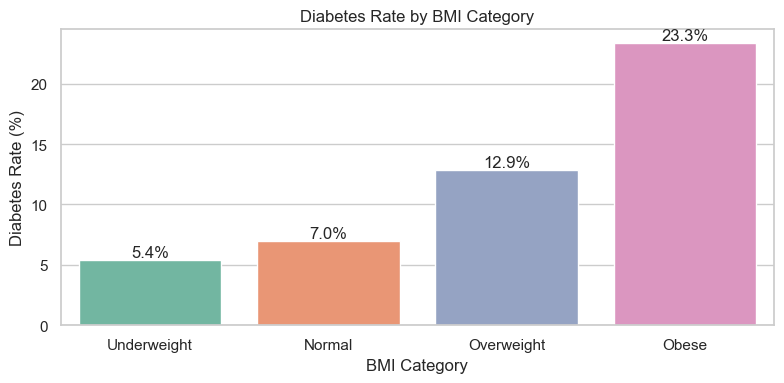

In [22]:
# Visualize diabetes rate by BMI category
plt.figure(figsize=(8, 4))

ax = sns.barplot(
    data=bmi_rate,
    x="BMI_Category",
    y="Diabetes_Status",
    palette="Set2"
)

plt.xlabel("BMI Category")
plt.ylabel("Diabetes Rate (%)")
plt.title("Diabetes Rate by BMI Category")

for p in ax.patches:
    ax.annotate(
        f"{p.get_height():.1f}%",
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

The chart shows a clear upward trend between BMI category and diabetes rate. Diabetes prevalence increases from 5.4% among underweight respondents to 23.3% among respondents with obesity.

### 8.3.4. Diabetes rate by age group

In [23]:
# Diabetes rate by age group
# Create age groups for analysis
ml_df["Age_Group"] = pd.cut(
    ml_df["Age"],
    bins=[17, 30, 40, 50, 60, 70, 80],
    labels=["18-30", "31-40", "41-50", "51-60", "61-70", "71-80"]
)
# Calculate diabetes rate by age group
age_rate = (
    ml_df.groupby("Age_Group")["Diabetes_Status"]
    .mean()
    .mul(100)
    .reset_index()
)

age_rate

,Age_Group,Diabetes_Status
0,18-30,1.483943
1,31-40,3.929647
2,41-50,9.249071
3,51-60,16.093088
4,61-70,20.545129
5,71-80,21.965638


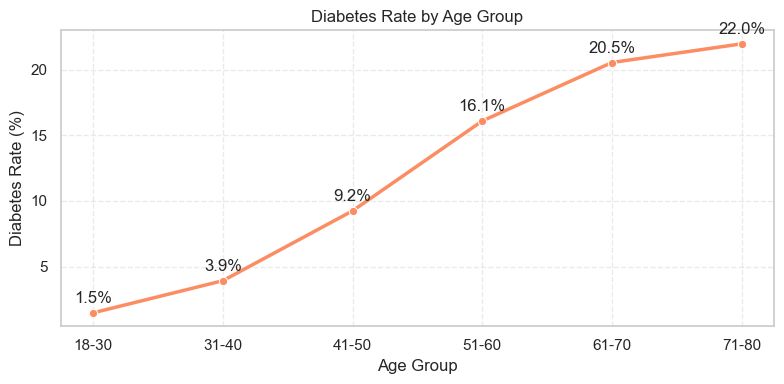

In [24]:
# Visualize diabetes rate by age group as a line graph

plt.figure(figsize=(8, 4))

ax = sns.lineplot(
    data=age_rate,
    x="Age_Group",
    y="Diabetes_Status",
    marker="o",
    linewidth=2.5,
    color="#fc8d62"
)

plt.xlabel("Age Group")
plt.ylabel("Diabetes Rate (%)")
plt.title("Diabetes Rate by Age Group")
plt.grid(True, linestyle="--", alpha=0.4)

for x, y in zip(age_rate["Age_Group"], age_rate["Diabetes_Status"]):
    plt.text(
        x,
        y + 0.5,
        f"{y:.1f}%",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()                                                                                          

Diabetes prevalence by age group. 
- The prevalence of Type 2 Diabetes increases progressively with age, rising from 1.5% among adults aged 18–30 years to 22.0% among those aged 71–80 years. This trend highlights age as a significant risk factor for type 2 diabetes.
- Clinical evidence: The risk of Type 2 Diabetes generally increases with age due to reduced insulin sensitivity, progressive pancreatic β-cell dysfunction, and the accumulation of metabolic risk factors over time.

### 8.3.5. Diabetes rate by general health

In [25]:
# Diabetes rate by general health
# Create a mapping for general health categories
health_map = {
    1: "Excellent",
    2: "Very Good",
    3: "Good",
    4: "Fair",
    5: "Poor"
}

ml_df["General_Health"] = ml_df["General_Health"].map(health_map)

health_rate = (
    ml_df.groupby("General_Health")["Diabetes_Status"]
    .mean()
    .mul(100)
    .reset_index()
)

health_order = ["Excellent", "Very Good", "Good", "Fair", "Poor"]
health_rate["General_Health"] = pd.Categorical(
    health_rate["General_Health"],
    categories=health_order,
    ordered=True
)

health_rate = health_rate.sort_values("General_Health")
health_rate

,General_Health,Diabetes_Status
0,Excellent,3.178429
4,Very Good,7.544169
2,Good,16.644056
1,Fair,28.716291
3,Poor,37.092538


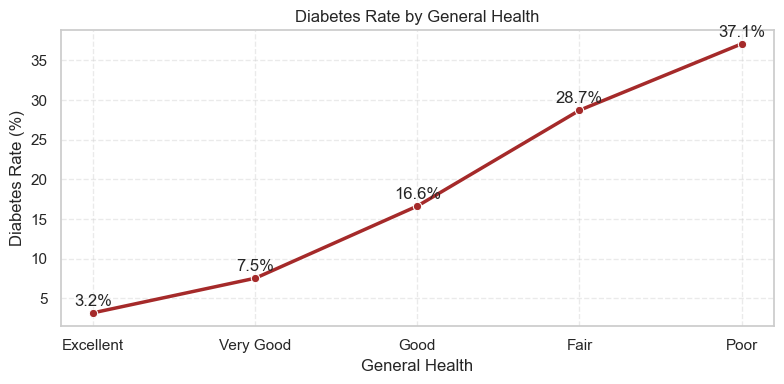

In [26]:
# Visualize diabetes rate by general health as a line graph

plt.figure(figsize=(8, 4))

ax = sns.lineplot(
    data=health_rate,
    x="General_Health",
    y="Diabetes_Status",
    marker="o",
    linewidth=2.5,
    color= 'brown'
)

plt.xlabel("General Health")
plt.ylabel("Diabetes Rate (%)")
plt.title("Diabetes Rate by General Health")
plt.grid(True, linestyle="--", alpha=0.4)

for x, y in zip(health_rate["General_Health"], health_rate["Diabetes_Status"]):
    plt.text(
        x,
        y + 0.5,
        f"{y:.1f}%",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

- Diabetes prevalence increased from 3.2% among participants reporting Excellent health to 37.1% among those reporting Poor health.
Participants reporting Poor health had the highest prevalence of diabetes.
- The steady upward trend indicates a strong association between poorer general health and Type 2 Diabetes.

### 8.3.6. Diabetes rate by ethnicity/ rate

In [27]:
# Diabetes rate by ethnicity / race
# Create a mapping for race/ethnicity categories
race_map = {
    1: "White",
    2: "Black",
    3: "American Indian / Alaska Native",
    4: "Asian",
    5: "Other race",
    6: "Multiracial"
}

ml_df["Ethnicity"] = ml_df["Race_Ethnicity"].map(race_map)

ethnicity_rate = (
    ml_df.groupby("Ethnicity")["Diabetes_Status"]
    .mean()
    .mul(100)
    .reset_index()
    .sort_values("Diabetes_Status", ascending=False)
)

ethnicity_rate

,Ethnicity,Diabetes_Status
2,Black,21.190975
1,Asian,21.106743
3,Multiracial,14.902625
4,Other race,14.219035
5,White,13.526705
0,American Indian / Alaska Native,11.208829


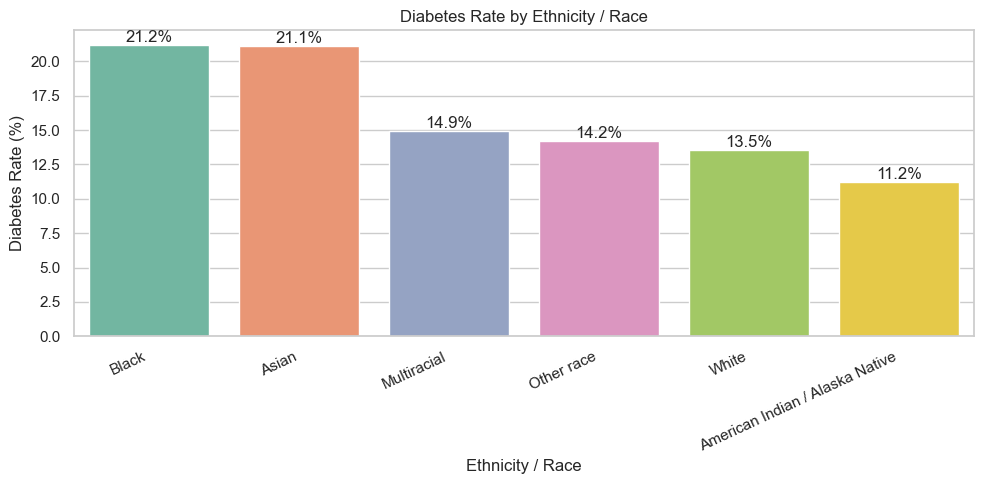

In [28]:
# Visualize diabetes rate by ethnicity / race
plt.figure(figsize=(10, 5))

ax = sns.barplot(
    data=ethnicity_rate,
    x="Ethnicity",
    y="Diabetes_Status",
    palette="Set2"
)

plt.xlabel("Ethnicity / Race")
plt.ylabel("Diabetes Rate (%)")
plt.title("Diabetes Rate by Ethnicity / Race")
plt.xticks(rotation=25, ha="right")

for p in ax.patches:
    ax.annotate(
        f"{p.get_height():.1f}%",
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()


The chart shows differences in diabetes prevalence across ethnicity/race groups. The highest diabetes rates appear among Black respondents (21.2%) and Asian respondents (21.1%), followed by Multiracial respondents (14.9%) and Other race respondents (14.2%).

### 8.3.7. Diabetes rate by kidney disease

In [29]:
# Diabetes rate by kidney disease
# Create a mapping for kidney disease categories
kidney_map = {
    0: "No Kidney Disease",
    1: "Kidney Disease"
}

ml_df["Kidney_Disease"] = ml_df["Kidney_Disease"].map(kidney_map)

kidney_rate = (
    ml_df.groupby("Kidney_Disease")["Diabetes_Status"]
    .mean()
    .mul(100)
    .reset_index()
)

kidney_rate

,Kidney_Disease,Diabetes_Status
0,Kidney Disease,41.500403
1,No Kidney Disease,12.856251


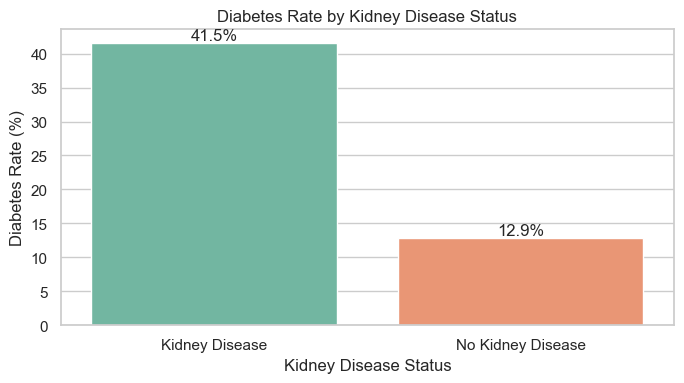

In [30]:
# Visualize diabetes rate by kidney disease
plt.figure(figsize=(7, 4))

ax = sns.barplot(
    data=kidney_rate,
    x="Kidney_Disease",
    y="Diabetes_Status",
    palette=["#66c2a5", "#fc8d62"]
)

plt.xlabel("Kidney Disease Status")
plt.ylabel("Diabetes Rate (%)")
plt.title("Diabetes Rate by Kidney Disease Status")

for p in ax.patches:
    ax.annotate(
        f"{p.get_height():.1f}%",
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

The chart shows a very strong association between kidney disease and diabetes. Respondents with kidney disease have a diabetes rate of 41.5%, compared with 12.9% among respondents without kidney disease.

### EDA Insights

The exploratory analysis typically shows diabetes prevalence rising with age, BMI, poorer general health, hypertension, high cholesterol and kidney disease. These patterns support the modeling strategy: combine clinical risk factors, demographics, socioeconomic proxies, and health behaviors into a risk-screening model rather than relying on a single predictor.


## 9. Modeling Preparation


Missingness indicator variables were added for predictors with relatively high missingness. This allows the model to retain information about whether a respondent skipped or had missing information for variables such as income, cholesterol, BMI, and smoking. The original missing values are still imputed later, but the indicator columns help the model learn whether missingness itself is associated with diabetes risk.

In [31]:
# Columns where missingness is high enough to track
missing_indicator_features = [
    "Income_Level",
    "High_Cholesterol",
    "BMI",
    "Ever_Smoked"
]

missing_indicator_features

['Income_Level', 'High_Cholesterol', 'BMI', 'Ever_Smoked']

In [32]:
# Create missingness indicator columns
model_df = ml_df.copy()

for col in missing_indicator_features:
    model_df[col + "_missing"] = model_df[col].isna().astype(int)

model_df.head()

,BMI,Age,Sex,Race_Ethnicity,General_Health,Physical_Health,Ever_Smoked,Physical_Activity,Education_Level,Income_Level,Hypertension,High_Cholesterol,Kidney_Disease,Heart_Disease,Diabetes_Status,BMI_Category,Age_Group,Ethnicity,Income_Level_missing,High_Cholesterol_missing,BMI_missing,Ever_Smoked_missing
0,30.47,80.0,2.0,1.0,Very Good,0.0,0.0,0.0,5.0,NaN,1.0,0.0,No Kidney Disease,0.0,1,Obese,71-80,White,1,0,0,0
1,28.56,80.0,2.0,1.0,Very Good,0.0,0.0,1.0,5.0,NaN,1.0,1.0,No Kidney Disease,0.0,0,Overweight,71-80,White,1,0,0,0
2,22.31,80.0,2.0,2.0,Fair,6.0,1.0,1.0,4.0,2.0,1.0,1.0,No Kidney Disease,0.0,0,Normal,71-80,Black,0,0,0,0
3,27.44,78.0,2.0,1.0,Very Good,2.0,0.0,1.0,5.0,NaN,0.0,0.0,No Kidney Disease,0.0,0,Overweight,71-80,White,1,0,0,0
4,25.85,76.0,2.0,1.0,Fair,0.0,0.0,1.0,5.0,7.0,1.0,0.0,No Kidney Disease,0.0,1,Overweight,71-80,White,0,0,0,0


In [33]:
# Original features plus missingness indicators
indicator_features = [
    col + "_missing" for col in missing_indicator_features
]

model_features = features + indicator_features

model_features

['BMI',
 'Age',
 'Sex',
 'Race_Ethnicity',
 'General_Health',
 'Physical_Health',
 'Ever_Smoked',
 'Physical_Activity',
 'Education_Level',
 'Income_Level',
 'Hypertension',
 'High_Cholesterol',
 'Kidney_Disease',
 'Heart_Disease',
 'Income_Level_missing',
 'High_Cholesterol_missing',
 'BMI_missing',
 'Ever_Smoked_missing']

In [34]:
# Define predictors and target
X = model_df[model_features]
y = model_df["Diabetes_Status"]

print(X.shape)
print(y.shape)

(418492, 18)
(418492,)


In [35]:
# Feature groups for preprocessing
numeric_features = [
    "BMI",
    "Age",
    "Physical_Health"
]

categorical_features = [
    col for col in model_features
    if col not in numeric_features + indicator_features
]

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)
print("Missing indicator features:", indicator_features)

Numeric features: ['BMI', 'Age', 'Physical_Health']
Categorical features: ['Sex', 'Race_Ethnicity', 'General_Health', 'Ever_Smoked', 'Physical_Activity', 'Education_Level', 'Income_Level', 'Hypertension', 'High_Cholesterol', 'Kidney_Disease', 'Heart_Disease']
Missing indicator features: ['Income_Level_missing', 'High_Cholesterol_missing', 'BMI_missing', 'Ever_Smoked_missing']


In [36]:
# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(f"Training rows: {X_train.shape[0]:,}")
print(f"Test rows: {X_test.shape[0]:,}")

Training rows: 334,793
Test rows: 83,699


In [37]:
# Check diabetes prevalence in training and test sets
print(f"Training diabetes prevalence: {y_train.mean():.2%}")
print(f"Test diabetes prevalence: {y_test.mean():.2%}")

Training diabetes prevalence: 14.29%
Test diabetes prevalence: 14.29%


The training and test sets have the same diabetes prevalence of 14.29%. This confirms that the stratified train-test split preserved the original class balance in both subsets. Maintaining the same target distribution is important because diabetes cases are the minority class, and an unbalanced split could lead to misleading model evaluation.

In [38]:
# Numeric preprocessing
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

In [39]:
# Categorical preprocessing
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

In [40]:
# Combine preprocessing steps
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
        ("missing_flags", "passthrough", indicator_features)
    ]
)

## 10. Train Baseline and Tree-Based Models


### 10.1. Logistic regression

Logistic Regression
Accuracy: 0.7290
ROC-AUC: 0.8221
              precision    recall  f1-score   support

           0       0.95      0.72      0.82     71742
           1       0.32      0.76      0.45     11957

    accuracy                           0.73     83699
   macro avg       0.63      0.74      0.63     83699
weighted avg       0.86      0.73      0.77     83699



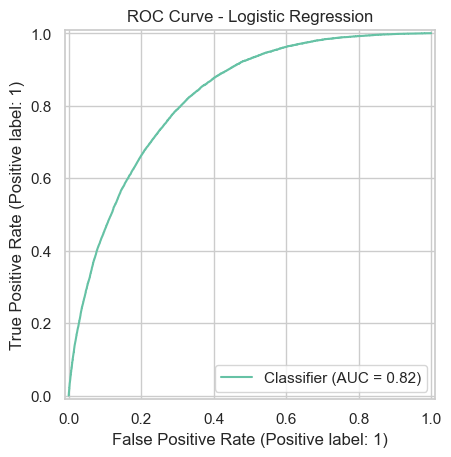

In [41]:
# Define and train the Logistic Regression model
log_reg = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ))
])

# Train the Logistic Regression model
log_reg.fit(X_train, y_train)

# Make predictions and evaluate the Logistic Regression model
log_reg_pred = log_reg.predict(X_test)
log_reg_proba = log_reg.predict_proba(X_test)[:, 1]

# Calculate evaluation metrics
log_reg_accuracy = accuracy_score(y_test, log_reg_pred)
log_reg_roc_auc = roc_auc_score(y_test, log_reg_proba)

# Print evaluation metrics
print("Logistic Regression")
print(f"Accuracy: {log_reg_accuracy:.4f}")
print(f"ROC-AUC: {log_reg_roc_auc:.4f}")
print(classification_report(y_test, log_reg_pred))

# Plot ROC curve for Logistic Regression
RocCurveDisplay.from_predictions(y_test, log_reg_proba)
plt.title("ROC Curve - Logistic Regression")
plt.show()

- The Logistic Regression model achieved 72.9% accuracy and a ROC-AUC of 0.8221, showing good predictive performance. It identified most diabetes cases (recall = 0.76) but produced many false positives (precision = 0.32), making it a suitable baseline model for diabetes screening.
- On the ROC- AUC graph: The x-axis represents the False Positive Rate (FPR), while the y-axis represents the True Positive Rate (TPR). The ROC curve shows that the Logistic Regression model achieves a high TPR while maintaining a relatively low FPR, resulting in an AUC of 0.82.

### 10.2. Decision Tree

Decision Tree
Accuracy: 0.6803
ROC-AUC: 0.8024
              precision    recall  f1-score   support

           0       0.95      0.66      0.78     71742
           1       0.28      0.81      0.42     11957

    accuracy                           0.68     83699
   macro avg       0.62      0.73      0.60     83699
weighted avg       0.86      0.68      0.73     83699



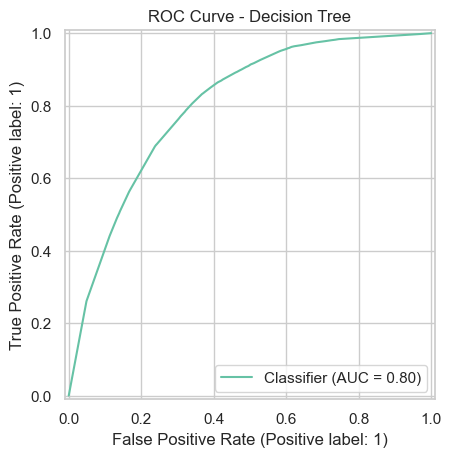

In [42]:
# Decision Tree Classifier
decision_tree = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", DecisionTreeClassifier(
        max_depth=6,
        min_samples_leaf=100,
        class_weight="balanced",
        random_state=42
    ))
])

# Train the Decision Tree model
decision_tree.fit(X_train, y_train)

# Make predictions and evaluate the Decision Tree model
decision_tree_pred = decision_tree.predict(X_test)
decision_tree_proba = decision_tree.predict_proba(X_test)[:, 1]

# Calculate evaluation metrics
decision_tree_accuracy = accuracy_score(y_test, decision_tree_pred)
decision_tree_roc_auc = roc_auc_score(y_test, decision_tree_proba)

# Print evaluation metrics
print("Decision Tree")
print(f"Accuracy: {decision_tree_accuracy:.4f}")
print(f"ROC-AUC: {decision_tree_roc_auc:.4f}")
print(classification_report(y_test, decision_tree_pred))

# Plot ROC curve for Decision Tree
RocCurveDisplay.from_predictions(y_test, decision_tree_proba)
plt.title("ROC Curve - Decision Tree")
plt.show()

Interpretation

- The Decision Tree achieved 68.0% accuracy and a ROC-AUC of 0.8024. It identified most diabetes cases (recall = 0.81) but had low precision (0.28), resulting in many false positives. Overall, it performed slightly worse than Logistic Regression.

ROC Curve Interpretation

- The ROC curve shows good discrimination (AUC = 0.80), although it performs slightly below the Logistic Regression model.

### 10.3. Random Forest

Random Forest
Accuracy: 0.7196
ROC-AUC: 0.8239
              precision    recall  f1-score   support

           0       0.95      0.71      0.81     71742
           1       0.31      0.78      0.44     11957

    accuracy                           0.72     83699
   macro avg       0.63      0.75      0.63     83699
weighted avg       0.86      0.72      0.76     83699



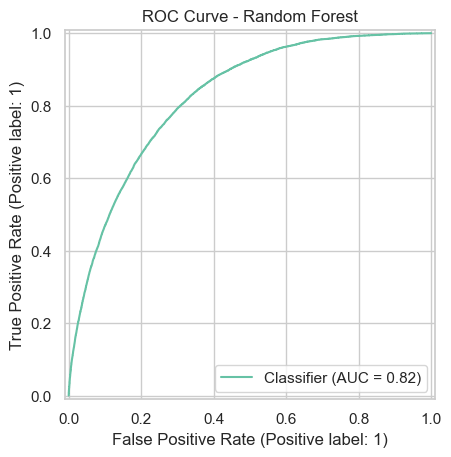

In [43]:
# Random Forest Classifier
random_forest = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=200,
        max_depth=12,
        min_samples_leaf=50,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ))
])

# Train the Random Forest model
random_forest.fit(X_train, y_train)

# Make predictions and evaluate the Random Forest model
random_forest_pred = random_forest.predict(X_test)
random_forest_proba = random_forest.predict_proba(X_test)[:, 1]

# Calculate evaluation metrics
random_forest_accuracy = accuracy_score(y_test, random_forest_pred)
random_forest_roc_auc = roc_auc_score(y_test, random_forest_proba)

# Print evaluation metrics
print("Random Forest")
print(f"Accuracy: {random_forest_accuracy:.4f}")
print(f"ROC-AUC: {random_forest_roc_auc:.4f}")
print(classification_report(y_test, random_forest_pred))

# Plot ROC curve for Random Forest
RocCurveDisplay.from_predictions(y_test, random_forest_proba)
plt.title("ROC Curve - Random Forest")
plt.show()

Interpretation

- The Random Forest model achieved 71.8% accuracy and a ROC-AUC of 0.8238. It showed high recall (0.78) but low precision (0.31), indicating many false positives. Overall, its performance was comparable to Logistic Regression.

ROC Curve Interpretation

- The ROC curve indicates good discrimination (AUC = 0.82), with performance comparable to Logistic Regression and better than the Decision Tree.

### 10.4. XGBoost 

XGBoost
Accuracy: 0.7187
ROC-AUC: 0.8291
              precision    recall  f1-score   support

           0       0.95      0.71      0.81     71742
           1       0.31      0.80      0.45     11957

    accuracy                           0.72     83699
   macro avg       0.63      0.75      0.63     83699
weighted avg       0.86      0.72      0.76     83699



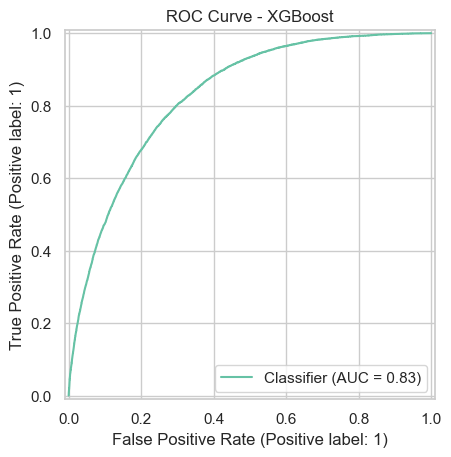

In [44]:
# Calculate scale_pos_weight for XGBoost to handle class imbalance
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

# Initializing and training the XGBoost model with the calculated scale_pos_weight
xgboost_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", XGBClassifier(
        n_estimators=200,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.85,
        colsample_bytree=0.85,
        scale_pos_weight=scale_pos_weight,
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    ))
])
# Train the XGBoost model
xgboost_model.fit(X_train, y_train)

# Make predictions and evaluate the XGBoost model
xgboost_pred = xgboost_model.predict(X_test)
xgboost_proba = xgboost_model.predict_proba(X_test)[:, 1]

# Calculate evaluation metrics
xgboost_accuracy = accuracy_score(y_test, xgboost_pred)
xgboost_roc_auc = roc_auc_score(y_test, xgboost_proba)

# Print evaluation metrics
print("XGBoost")
print(f"Accuracy: {xgboost_accuracy:.4f}")
print(f"ROC-AUC: {xgboost_roc_auc:.4f}")
print(classification_report(y_test, xgboost_pred))

# Plot ROC curve for XGBoost
RocCurveDisplay.from_predictions(y_test, xgboost_proba)
plt.title("ROC Curve - XGBoost")
plt.show()

Interpretation

- The XGBoost model achieved 72.0% accuracy and the highest ROC-AUC (0.8291) among all models. It maintained high recall (0.80) while outperforming the other models in overall discrimination, making it the best-performing model.

ROC Curve Interpretation

- The ROC curve demonstrates excellent discrimination (AUC = 0.83), outperforming the Logistic Regression, Decision Tree, and Random Forest models.

## 11. Best Model Evaluation


In [45]:
# Summarize model performance metrics in a DataFrame
results_df = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "XGBoost"
    ],
    "Accuracy": [
        log_reg_accuracy,
        decision_tree_accuracy,
        random_forest_accuracy,
        xgboost_accuracy
    ],
    "ROC-AUC": [
        log_reg_roc_auc,
        decision_tree_roc_auc,
        random_forest_roc_auc,
        xgboost_roc_auc
    ]
})

# Display the results sorted by ROC-AUC
results_df.sort_values("ROC-AUC", ascending=False)

,Model,Accuracy,ROC-AUC
3,XGBoost,0.718730,0.829078
2,Random Forest,0.719626,0.823893
0,Logistic Regression,0.729041,0.822059
1,Decision Tree,0.680331,0.802421


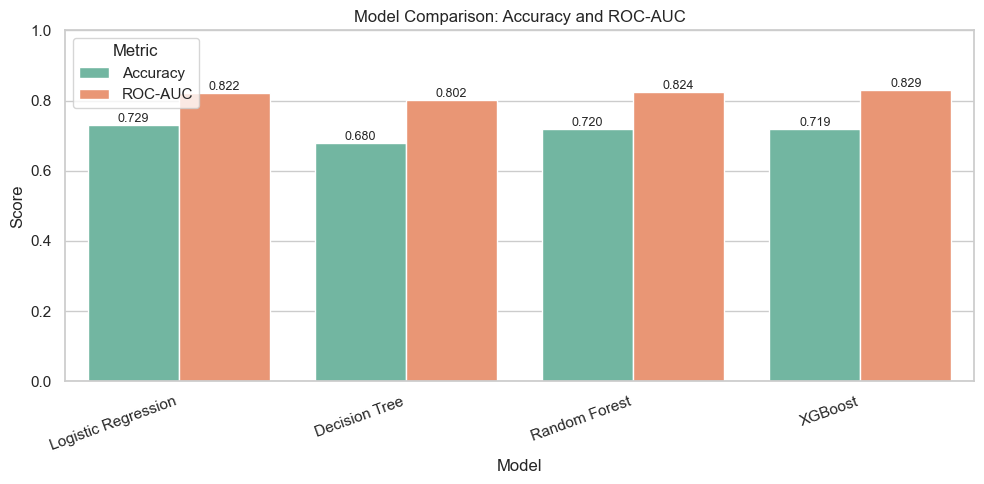

In [46]:
# Plot Accuracy and ROC-AUC together

results_melted = results_df.melt(
    id_vars="Model",
    value_vars=["Accuracy", "ROC-AUC"],
    var_name="Metric",
    value_name="Score"
)

# Visualize model performance metrics
plt.figure(figsize=(10, 5))

ax = sns.barplot(
    data=results_melted,
    x="Model",
    y="Score",
    hue="Metric",
    palette="Set2"
)

plt.title("Model Comparison: Accuracy and ROC-AUC")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=20, ha="right")
plt.legend(title="Metric")

for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(
            f"{height:.3f}",
            (p.get_x() + p.get_width() / 2, height),
            ha="center",
            va="bottom",
            fontsize=9
        )

plt.tight_layout()
plt.show()

- The model comparison shows that all models performed reasonably well, with ROC-AUC scores above 0.80. 
- XGBoost achieved the highest ROC-AUC score (0.829), meaning it had the strongest ability to distinguish between respondents with and without diabetes. 
- Random Forest performed nearly as well (ROC-AUC = 0.824), while Logistic Regression also showed strong performance (ROC-AUC = 0.822) and had the highest accuracy score (0.729). 
- The Decision Tree had the weakest performance, with the lowest accuracy (0.680) and ROC-AUC (0.802). 
- Overall, XGBoost is the best-performing model by ROC-AUC, while Logistic Regression remains a strong and more interpretable baseline.

### Hyperparameter tuning best model

In [47]:
# Define the scale_pos_weight for XGBoost to handle class imbalance
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

# Define the XGBoost pipeline with preprocessing and model
xgb_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", XGBClassifier(
        eval_metric="logloss",
        scale_pos_weight=scale_pos_weight,
        random_state=42,
        n_jobs=-1
    ))
])

In [48]:
# Define the hyperparameter grid for XGBoost
xgb_param_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [3, 4, 5],
    "model__learning_rate": [0.03, 0.05, 0.1],
    "model__subsample": [0.8, 1.0],
    "model__colsample_bytree": [0.8, 1.0]
}

In [49]:
# Perform grid search with cross-validation for XGBoost
xgb_grid_search = GridSearchCV(
    estimator=xgb_pipeline,
    param_grid=xgb_param_grid,
    scoring="roc_auc",
    cv=3,
    n_jobs=-1,
    verbose=2
)

# Fit the grid search to the training data
xgb_grid_search.fit(X_train, y_train)

Fitting 3 folds for each of 72 candidates, totalling 216 fits


,estimator,"Pipeline(step...=None, ...))])"
,param_grid,"{'model__colsample_bytree': [0.8, 1.0], 'model__learning_rate': [0.03, 0.05, ...], 'model__max_depth': [3, 4, ...], 'model__n_estimators': [100, 200], ...}"
,scoring,'roc_auc'
,n_jobs,-1
,refit,True
,cv,3
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('num', ...), ('cat', ...), ...]"


The XGBoost hyperparameter tuning process evaluated 72 parameter combinations using 3-fold cross-validation, resulting in 216 total model fits. This allows the model to search across different tree depths, learning rates, numbers of estimators, and sampling settings to identify the parameter combination with the best cross-validated ROC-AUC score.

In [50]:
# Display the best ROC-AUC score and the best hyperparameters found during grid search
print("Best ROC-AUC:", xgb_grid_search.best_score_)
print("Best parameters:")
print(xgb_grid_search.best_params_)

Best ROC-AUC: 0.8316285869415988
Best parameters:
{'model__colsample_bytree': 0.8, 'model__learning_rate': 0.05, 'model__max_depth': 5, 'model__n_estimators': 200, 'model__subsample': 0.8}


In [51]:
# Evaluate the best XGBoost model on the test set
best_xgb = xgb_grid_search.best_estimator_

best_xgb_pred = best_xgb.predict(X_test)
best_xgb_proba = best_xgb.predict_proba(X_test)[:, 1]

best_xgb_accuracy = accuracy_score(y_test, best_xgb_pred)
best_xgb_roc_auc = roc_auc_score(y_test, best_xgb_proba)

# Print evaluation metrics for the best XGBoost model
print("Tuned XGBoost")
print(f"Accuracy: {best_xgb_accuracy:.4f}")
print(f"ROC-AUC: {best_xgb_roc_auc:.4f}")
print(classification_report(y_test, best_xgb_pred))

Tuned XGBoost
Accuracy: 0.7199
ROC-AUC: 0.8294
              precision    recall  f1-score   support

           0       0.95      0.71      0.81     71742
           1       0.31      0.80      0.45     11957

    accuracy                           0.72     83699
   macro avg       0.63      0.75      0.63     83699
weighted avg       0.86      0.72      0.76     83699



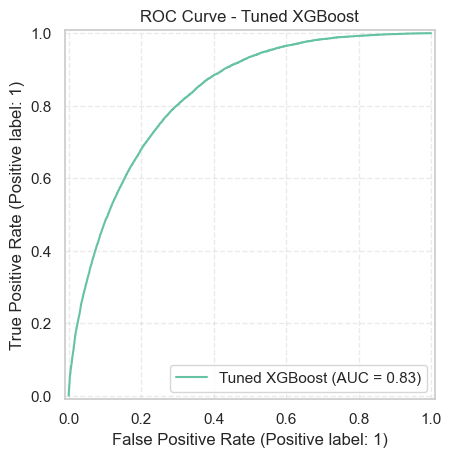

In [54]:
# Plot the ROC curve for the tuned XGBoost model
RocCurveDisplay.from_predictions(
    y_test,
    best_xgb_proba,
    name="Tuned XGBoost"
)

plt.title("ROC Curve - Tuned XGBoost")
plt.grid(True, linestyle="--", alpha=0.4)
plt.show()

In [52]:
# Compare the original and tuned XGBoost models
xgb_comparison = pd.DataFrame({
    "Model": ["Original XGBoost", "Tuned XGBoost"],
    "Accuracy": [xgboost_accuracy, best_xgb_accuracy],
    "ROC-AUC": [xgboost_roc_auc, best_xgb_roc_auc]
})

xgb_comparison

,Model,Accuracy,ROC-AUC
0,Original XGBoost,0.718730,0.829078
1,Tuned XGBoost,0.719901,0.829377


Interpretation

- The tuned XGBoost model achieved 72.0% accuracy and the highest ROC-AUC (0.8293). Hyperparameter tuning resulted in a slight improvement over the default XGBoost model, confirming it as the best-performing model.

ROC Curve Interpretation

- The tuned XGBoost model achieved the highest ROC-AUC (0.83), demonstrating the best discrimination between diabetic and non-diabetic individuals among all models.

Hyperparameter Tuning Insight

- Hyperparameter tuning produced a small but measurable improvement in model performance, indicating that the default XGBoost model was already close to optimal. The tuned model was selected as the final model due to its highest ROC-AUC and overall performance.

## 12. Feature Importance and Interpretation


In [53]:
# Get the feature names after preprocessing for the best XGBoost model
best_xgb.named_steps["preprocessor"].get_feature_names_out()

array(['num__BMI', 'num__Age', 'num__Physical_Health', 'cat__Sex_1.0',
       'cat__Sex_2.0', 'cat__Race_Ethnicity_1.0',
       'cat__Race_Ethnicity_2.0', 'cat__Race_Ethnicity_3.0',
       'cat__Race_Ethnicity_4.0', 'cat__Race_Ethnicity_5.0',
       'cat__Race_Ethnicity_6.0', 'cat__General_Health_Excellent',
       'cat__General_Health_Fair', 'cat__General_Health_Good',
       'cat__General_Health_Poor', 'cat__General_Health_Very Good',
       'cat__Ever_Smoked_0.0', 'cat__Ever_Smoked_1.0',
       'cat__Physical_Activity_0.0', 'cat__Physical_Activity_1.0',
       'cat__Education_Level_1.0', 'cat__Education_Level_2.0',
       'cat__Education_Level_3.0', 'cat__Education_Level_4.0',
       'cat__Education_Level_5.0', 'cat__Education_Level_6.0',
       'cat__Income_Level_1.0', 'cat__Income_Level_2.0',
       'cat__Income_Level_3.0', 'cat__Income_Level_4.0',
       'cat__Income_Level_5.0', 'cat__Income_Level_6.0',
       'cat__Income_Level_7.0', 'cat__Income_Level_8.0',
       'cat__Income_

In [54]:
# Map the feature names to more readable labels
feature_names = (
    pd.Series(best_xgb.named_steps["preprocessor"].get_feature_names_out())

    # Remove transformer prefixes
    .str.replace("num__", "", regex=False)
    .str.replace("cat__", "", regex=False)
    .str.replace("missing_flags__", "", regex=False)

    # Binary variables
    .str.replace("Hypertension_0.0", "Hypertension: No", regex=False)
    .str.replace("Hypertension_1.0", "Hypertension: Yes", regex=False)

    .str.replace("High_Cholesterol_0.0", "High Cholesterol: No", regex=False)
    .str.replace("High_Cholesterol_1.0", "High Cholesterol: Yes", regex=False)

    .str.replace("Ever_Smoked_0.0", "Ever Smoked: No", regex=False)
    .str.replace("Ever_Smoked_1.0", "Ever Smoked: Yes", regex=False)

    .str.replace("Physical_Activity_0.0", "Physical Activity: No", regex=False)
    .str.replace("Physical_Activity_1.0", "Physical Activity: Yes", regex=False)

    .str.replace("Heart_Disease_0.0", "Heart Disease: No", regex=False)
    .str.replace("Heart_Disease_1.0", "Heart Disease: Yes", regex=False)

    .str.replace("Kidney_Disease_Kidney Disease", "Kidney Disease: Yes", regex=False)
    .str.replace("Kidney_Disease_No Kidney Disease", "Kidney Disease: No", regex=False)

    # Multi-category variables
    .str.replace("General_Health_", "General Health: ", regex=False)
    .str.replace("Race_Ethnicity_", "Race/Ethnicity: ", regex=False)
    .str.replace("Education_Level_", "Education Level: ", regex=False)
    .str.replace("Income_Level_", "Income Level: ", regex=False)

    # Missing indicators
    .str.replace("Income_Level_missing", "Income Missing", regex=False)
    .str.replace("High_Cholesterol_missing", "High Cholesterol Missing", regex=False)
    .str.replace("BMI_missing", "BMI Missing", regex=False)
    .str.replace("Ever_Smoked_missing", "Smoking Missing", regex=False)

    .tolist()
)

In [55]:
# Get the trained XGBoost model
xgb_model = best_xgb.named_steps["model"]

# Create feature importance DataFrame
feature_importance = (
    pd.DataFrame({
        "Feature": feature_names,
        "Importance": xgb_model.feature_importances_
    })
    .sort_values(by="Importance", ascending=False)
    .reset_index(drop=True)
)

# Display the top 10 features
feature_importance.head(10)

,Feature,Importance
0,Hypertension: Yes,0.400863
1,Hypertension: No,0.219209
2,General Health: Very Good,0.053416
3,High Cholesterol: Yes,0.040080
4,General Health: Excellent,0.038571
5,High Cholesterol: No,0.025124
6,Age,0.022709
7,General Health: Good,0.018472
8,Kidney Disease: Yes,0.015762
9,General Health: Fair,0.015349


In [56]:
# Aggregate one-hot encoded features
feature_importance["Feature"] = (
    feature_importance["Feature"]
    .replace({
        r"General Health:.*": "General Health",
        r"Hypertension:.*": "Hypertension",
        r"High Cholesterol:.*": "High Cholesterol",
        r"Kidney Disease:.*": "Kidney Disease",
        r"Heart Disease:.*": "Heart Disease",
        r"Physical Activity:.*": "Physical Activity",
        r"Ever Smoked:.*": "Ever Smoked",
        r"Race/Ethnicity:.*": "Race/Ethnicity",
        r"Education Level:.*": "Education Level",
        r"Income Level:.*": "Income Level",
    }, regex=True)
)

feature_importance_grouped = (
    feature_importance
    .groupby("Feature", as_index=False)["Importance"]
    .sum()
    .sort_values("Importance", ascending=False)
)

feature_importance_grouped

,Feature,Importance
9,Hypertension,0.620072
5,General Health,0.136664
7,High Cholesterol,0.065205
6,Heart Disease,0.023952
0,Age,0.022709
11,Kidney Disease,0.021753
12,Physical Activity,0.021749
14,Race/Ethnicity,0.020041
10,Income Level,0.019521
3,Education Level,0.015373


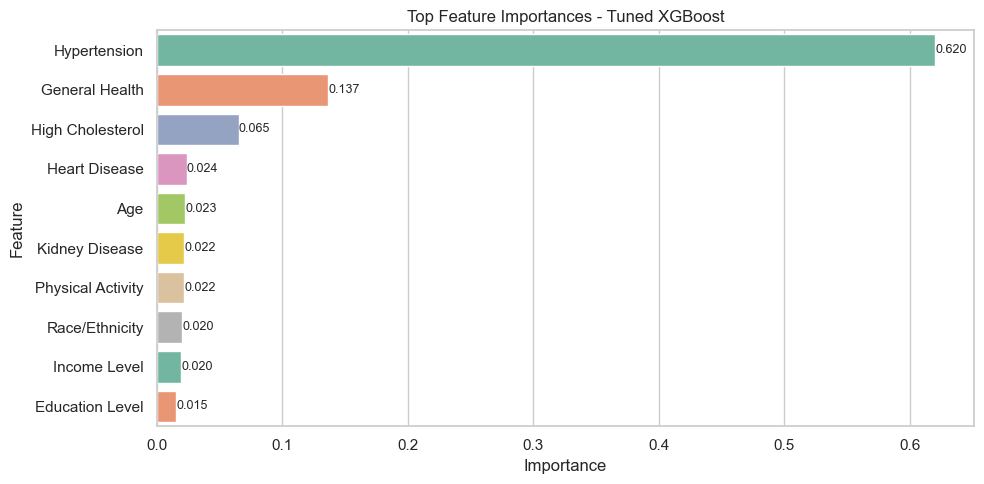

In [57]:
# Top 10 features
top_features = feature_importance_grouped.head(10)

plt.figure(figsize=(10, 5))

ax = sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature",
    palette="Set2"
)

# Title and labels
plt.title("Top Feature Importances - Tuned XGBoost")
plt.xlabel("Importance")
plt.ylabel("Feature")

# Annotate bars
for p in ax.patches:
    width = p.get_width()
    if width > 0:
        ax.annotate(
            f"{width:.3f}",
            (width, p.get_y() + p.get_height() / 2),
            ha="left",
            va="center",
            fontsize=9
        )

plt.tight_layout()
plt.show()

The tuned XGBoost model identified hypertension status as the most important predictor of diabetes risk, with an importance score of 0.368. This feature contributed far more than any other variable, suggesting that blood-pressure status is highly informative for distinguishing between respondents with and without diabetes.

General health and cholesterol status were also among the strongest predictors. Several general-health categories appeared in the top features, showing that self-reported health captures meaningful differences in diabetes risk. Cholesterol status, kidney disease, heart disease, physical inactivity, age, BMI, race/ethnicity, education, and income also contributed to the model, although with lower importance scores.

Overall, the feature importance results align well with the EDA findings: diabetes risk is strongly associated with cardiometabolic factors such as hypertension, cholesterol, BMI, kidney disease, heart disease, and age. These results support using the model as a risk-screening tool while also emphasizing the importance of preventive care for adults with multiple cardiometabolic risk factors.

### Modeling Insights


- All models performed well, with ROC-AUC scores above 0.80, showing that BRFSS variables can predict diabetes risk.

- XGBoost performed best with the highest ROC-AUC score of 0.829, followed closely by Random Forest at 0.824.

- Logistic Regression had strong performance and the highest accuracy score of 0.729, making it a useful interpretable baseline.

- Decision Tree performed weakest, likely because a single tree is less stable than ensemble models.

- Feature importance showed hypertension as the strongest predictor, followed by general health, cholesterol, kidney disease, heart disease, age, BMI, and physical activity.

- XGBoost is the preferred final model, but recall and ROC-AUC should be prioritized because diabetes is the minority class.

## Global and Local Interpretability

### LIME AND SHARP
To improve model interpretability, SHAP and LIME were applied to the tuned XGBoost model.
SHAP explains overall feature importance, while LIME explains individual predictions. Together, they improve the interpretability of the tuned XGBoost model.

### SHAP(SHapley Additive exPlanations)
SHAP was used to explain the tuned XGBoost model globally by showing which features contributed most to predictions across the test set.

In [58]:
# Transform data using the fitted preprocessor
X_train_transformed = best_xgb.named_steps["preprocessor"].transform(X_train)
X_test_transformed = best_xgb.named_steps["preprocessor"].transform(X_test)

# Get feature names after preprocessing
feature_names = best_xgb.named_steps["preprocessor"].get_feature_names_out()

# Convert sparse matrix to dense
if hasattr(X_train_transformed, "toarray"):
    X_train_transformed = X_train_transformed.toarray()
    X_test_transformed = X_test_transformed.toarray()

# Get trained XGBoost model
xgb_final_model = best_xgb.named_steps["model"]

In [59]:
# SHAP explanation using generic Explainer

shap_explainer = shap.Explainer(
    xgb_final_model.predict,
    X_train_transformed,
    feature_names=feature_names
)

shap_values = shap_explainer(X_test_transformed[:1000])

PermutationExplainer explainer: 1001it [00:40, 20.69it/s]                         


In [60]:
# Map feature names to more readable labels for SHAP plots
feature_names = (
    pd.Series(best_xgb.named_steps["preprocessor"].get_feature_names_out())

    .str.replace("num__", "", regex=False)
    .str.replace("cat__", "", regex=False)
    .str.replace("missing_flags__", "", regex=False)

    # Sex
    .str.replace("Sex_1.0", "Sex: Male", regex=False)
    .str.replace("Sex_2.0", "Sex: Female", regex=False)

    # Race
    .str.replace("Race_Ethnicity_1.0", "Race/Ethnicity: White", regex=False)
    .str.replace("Race_Ethnicity_2.0", "Race/Ethnicity: Black", regex=False)
    .str.replace("Race_Ethnicity_3.0", "Race/Ethnicity: American Indian/Alaska Native", regex=False)
    .str.replace("Race_Ethnicity_4.0", "Race/Ethnicity: Asian", regex=False)
    .str.replace("Race_Ethnicity_5.0", "Race/Ethnicity: Native Hawaiian/Pacific Islander", regex=False)
    .str.replace("Race_Ethnicity_6.0", "Race/Ethnicity: Other", regex=False)

    # Education
    .str.replace("Education_Level_1.0", "Education: Never Attended School", regex=False)
    .str.replace("Education_Level_2.0", "Education: Elementary", regex=False)
    .str.replace("Education_Level_3.0", "Education: Some High School", regex=False)
    .str.replace("Education_Level_4.0", "Education: High School Graduate", regex=False)
    .str.replace("Education_Level_5.0", "Education: Some College", regex=False)
    .str.replace("Education_Level_6.0", "Education: College Graduate", regex=False)

    # Income
    .str.replace("Income_Level_1.0", "Income: <$10,000", regex=False)
    .str.replace("Income_Level_2.0", "Income: $10k-$15k", regex=False)
    .str.replace("Income_Level_3.0", "Income: $15k-$20k", regex=False)
    .str.replace("Income_Level_4.0", "Income: $20k-$25k", regex=False)
    .str.replace("Income_Level_5.0", "Income: $25k-$35k", regex=False)
    .str.replace("Income_Level_6.0", "Income: $35k-$50k", regex=False)
    .str.replace("Income_Level_7.0", "Income: $50k-$75k", regex=False)
    .str.replace("Income_Level_8.0", "Income: $75k-$100k", regex=False)
    .str.replace("Income_Level_9.0", "Income: $100k-$150k", regex=False)
    .str.replace("Income_Level_10.0", "Income: >$150k", regex=False)

    # Hypertension
    .str.replace("Hypertension_0.0", "Hypertension: No", regex=False)
    .str.replace("Hypertension_1.0", "Hypertension: Yes", regex=False)

    # High cholesterol
    .str.replace("High_Cholesterol_0.0", "High Cholesterol: No", regex=False)
    .str.replace("High_Cholesterol_1.0", "High Cholesterol: Yes", regex=False)

    # Smoking
    .str.replace("Ever_Smoked_0.0", "Ever Smoked: No", regex=False)
    .str.replace("Ever_Smoked_1.0", "Ever Smoked: Yes", regex=False)

    # Physical activity
    .str.replace("Physical_Activity_0.0", "Physical Activity: No", regex=False)
    .str.replace("Physical_Activity_1.0", "Physical Activity: Yes", regex=False)

    # General health
    .str.replace("General_Health_", "General Health: ", regex=False)

    # Kidney disease
    .str.replace("Kidney_Disease_Kidney Disease", "Kidney Disease: Yes", regex=False)
    .str.replace("Kidney_Disease_No Kidney Disease", "Kidney Disease: No", regex=False)

    # Heart disease
    .str.replace("Heart_Disease_0.0", "Heart Disease: No", regex=False)
    .str.replace("Heart_Disease_1.0", "Heart Disease: Yes", regex=False)

    # Physical health
    .str.replace("Physical_Health", "Physical Health (days)", regex=False)

    .tolist()
)

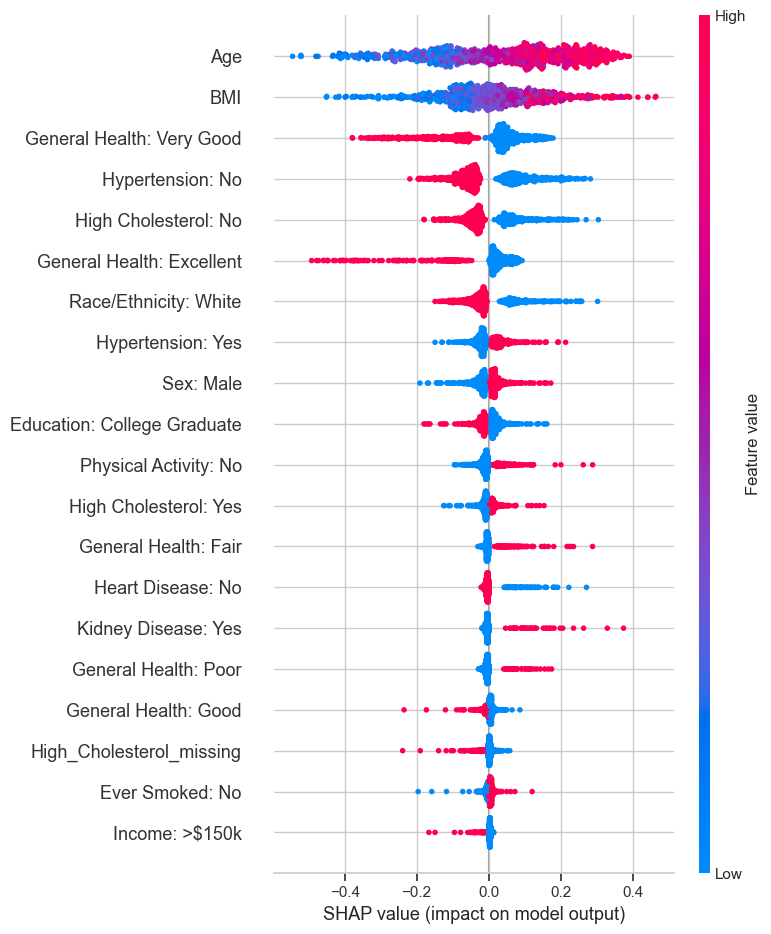

In [61]:
# SHAP summary plot
shap.summary_plot(
    shap_values.values,
    X_test_transformed[:1000],
    feature_names=feature_names
)

SHAP values explain the impact of each feature on the model's prediction for individual instances.

- Positive SHAP values (red/right side) → Increase diabetes risk prediction

- Negative SHAP values (blue/left side) → Decrease diabetes risk prediction

- Color represents the feature value (red = high, blue = low)

### Feature-Specific Insights from SHAP

| Feature | Importance | SHAP Insight |
|---------|------------|--------------|
| **Age** | Highest | Older age increases diabetes risk. |
| **Hypertension** | High | Hypertension increases risk. |
| **BMI** | High | Higher BMI increases risk. |
| **General Health** | High | Poor health increases risk. |
| **High Cholesterol** | High | High cholesterol increases risk. |
| **Physical Activity** | Moderate | Physical activity reduces risk. |
| **Education level** | Moderate | Higher education slightly reduces risk. |
| **Income level** | Moderate | Higher income slightly reduces risk. |
| **Heart Disease** | Moderate | Heart disease increases risk. |
| **Kidney Disease** | Moderate | Kidney disease increases risk. |

### LIME (Local Interpretable Model-Agnostic Explanations)
LIME was used to explain individual predictions by showing which features pushed a specific respondent's prediction toward diabetes or no diabetes.

In [62]:
# LIME explanation using LimeTabularExplainer
lime_explainer = LimeTabularExplainer(
    training_data=X_train_transformed,
    feature_names=feature_names,
    class_names=["No Diabetes", "Diabetes"],
    mode="classification",
    discretize_continuous=False,
    random_state=42
)


In [63]:
i = 30  # Randomly selected index to explain a specific instance from the test set.

lime_exp = lime_explainer.explain_instance(
    data_row=X_test_transformed[i],
    predict_fn=xgb_final_model.predict_proba,
    num_features=10
)

lime_exp.show_in_notebook(show_table=True)

### LIME Individual Prediction Insight


- The LIME explanation shows that the model predicted a 66% probability of diabetes for this individual. 
- The prediction was driven primarily by age and BMI, which were the strongest contributors, followed by hypertension status, cholesterol status, race/ethnicity, and heart disease status. 
- Other variables, including general health, smoking history, and kidney disease, had comparatively smaller effects on the prediction.

| Feature | Contribution | Interpretation |
|---------|-------------:|---------------|
| **Age** | **0.12** | Strongest contributor; older age increased the predicted diabetes risk. |
| **BMI** | **0.08** | Higher BMI increased the predicted diabetes risk. |
| **Hypertension: No** | **0.04** | Small contribution; reflects one-hot encoding of hypertension status. |
| **High Cholesterol: No** | **0.04** | Moderate contribution to the prediction. |
| **Race/Ethnicity: White** | **0.03** | Slight contribution to the prediction. |
| **Heart Disease: No** | **0.03** | Small contribution to the prediction. |
| **General Health: Very Good** | **0.02** | Minor influence on the prediction. |
| **Hypertension: Yes** | **0.01** | Small contribution; represents hypertension status. |
| **Ever Smoked: No** | **0.01** | Minimal influence on the prediction. |
| **Kidney Disease: No** | **0.01** | Minimal influence on the prediction. |

The table below the chart shows the values of the transformed features used by the model.
  - Age = -0.13
  - BMI = -0.14
These are standardized values, not the individual's actual age or BMI. Negative values indicate that the individual's value is below the average of the training dataset after scaling.




## Model Deployment using Streamlit

After selecting the tuned XGBoost model as the final model, it was deployed using Streamlit, an open-source Python framework for building interactive web applications. The trained model was serialized using joblib and integrated into a Streamlit application. The application allows users to enter patient information, including demographic, lifestyle, and health-related factors, through an intuitive interface. These inputs are processed and passed to the trained model, which predicts the likelihood of Type 2 Diabetes and returns both the predicted class and the probability score. Deploying the model through Streamlit makes it accessible to end users without requiring knowledge of machine learning or programming.

### Deployment Workflow

1. **User Input** – The user enters demographic, lifestyle, and health information.
2. **Streamlit Interface** – The application collects and validates the inputs.
3. **Input Preprocessing** – The inputs are formatted to match the model's expected features.
4. **Trained XGBoost Model (.pkl)** – The preprocessed data is passed to the saved model.
5. **Prediction & Probability** – The model predicts diabetes risk and computes the probability.
6. **Display Results** – The application presents the prediction and risk probability to the user.

In [64]:
# Save the tuned XGBoost model to a file for use in Streamlit app
joblib.dump(best_xgb, "tuned_xgboost.pkl")

['tuned_xgboost.pkl']

In [65]:
# Check the columns of the training data for reference in the Streamlit app
X_train.columns.tolist()

['BMI',
 'Age',
 'Sex',
 'Race_Ethnicity',
 'General_Health',
 'Physical_Health',
 'Ever_Smoked',
 'Physical_Activity',
 'Education_Level',
 'Income_Level',
 'Hypertension',
 'High_Cholesterol',
 'Kidney_Disease',
 'Heart_Disease',
 'Income_Level_missing',
 'High_Cholesterol_missing',
 'BMI_missing',
 'Ever_Smoked_missing']

In [ ]:
# Create app.py for Streamlit deployment with the required code to
#  load the model and make predictions based on user input.

In [67]:
# Launch Streamlit app
!streamlit run app.py

Usage: streamlit run [OPTIONS] [TARGET] [ARGS]...
Try 'streamlit run --help' for help.

Error: Invalid value: File does not exist: app.py


## Project Insights

- **Age** was the strongest predictor of Type 2 Diabetes, with risk increasing among older individuals.

- **Hypertension, high BMI, poor general health, and high cholesterol** were the key clinical risk factors associated with diabetes.

- **Physical activity** reduced diabetes risk, while higher **education** and **income** were associated with a slightly lower risk.

- **Tuned XGBoost** achieved the best overall performance, with an **Accuracy of 72.03%** and a **ROC-AUC of 0.8293**.

- All models achieved **high recall (≥0.76)**, effectively identifying diabetes cases, although precision remained relatively low due to false positives.

- **Hyperparameter tuning** slightly improved XGBoost performance, confirming it as the final model.

- **SHAP** identified **age, hypertension, BMI, general health, and high cholesterol** as the most influential features.

- **LIME** provided local explanations, showing how individual features influenced specific predictions.

- The findings demonstrate that machine learning can support the **early identification of individuals at high risk of Type 2 Diabetes**, enabling timely preventive interventions.

## 13. Recommendations

1. **Prioritize screening for adults with multiple clinical risk factors.** Respondents with hypertension, high cholesterol, high BMI, kidney disease, or heart disease show elevated diabetes prevalence and should be strong candidates for follow-up screening.
2. **Use the model as a risk-stratification support tool, not a diagnosis.** The output should guide outreach and preventive-care prioritization; diagnosis still requires clinical testing.
3. **Tune the decision threshold to the operational goal.** If the program goal is early detection, choose a threshold that improves diabetes recall, accepting more false positives.
4. **Pair model outputs with intervention pathways.** Risk identification is most useful when connected to A1C testing, nutrition counseling, physical-activity programs, blood-pressure management, and cholesterol management.
5. **Monitor fairness and subgroup performance.** Because diabetes burden and healthcare access vary across demographic groups, evaluate recall, precision, and false-positive rates across race/ethnicity, sex, and age groups before deployment.


## 15. Conclusion

The BRFSS variables provide a useful foundation for predicting Type 2 diabetes risk. Clinical indicators such as BMI, hypertension, high cholesterol, general health, kidney disease, heart disease, and age are consistently informative, while socioeconomic and behavioral variables add context for outreach planning.

Among the candidate models, the best model should be selected using ROC-AUC together with diabetes-class recall and precision. In a screening context, the preferred model is the one that identifies the largest share of likely diabetes cases while keeping follow-up workload manageable. The final model can support preventive health programs by ranking adults for screening and intervention, but it should be validated on new data and assessed for subgroup fairness before real-world use.
